# ДЗ 1. Оптимальная стратегия перемещения таксиста по городу Новинск

In [1]:
!pip install gym==0.22.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 631.1/631.1 kB 20.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for gym: filename=gym-0.22.0-py3-none-any.whl size=708479 sha256=6e284c2f8a951c9c2bea590634d66b236fd4b8d44b896b6e7697a5b482758dd5
  Stored in directory: /root/.cache/pip/wheels/fd/bd/03/a325acb1df8746ce0573ffdf8730f4e7d32f4aa839a56f1b2f
Successfully built gym
  Attempting uninstall: gym
    Found existing installation: gym 0.25.2
    Uninstalling gym-0.25.2:
      Successfully uninstalled gym-0.25.2


## Задание 1. Описание марковского процесса

Контекст. Таксист передвигается по сетке из NxN ячеек. Он способен перемещаться на одну ячейку вверх, вниз, влево или вправо (если он не находится на краю). По этой сетке разбросаны пассажиры и их пункты назначения.

Размер сетки для этой задачи: N = 7 или N = 5.

Особенности сетки: определенные ячейки содержат пассажиров, в то время как другие ячейки являются местами назначения.

Места пассажиров: всего существует 4 возможных места для пассажиров — A, B, C, D.
Пункты назначения: существует 4 возможных пункта назначения — a, b, c, d.
Пассажир может находиться в любом из четырех мест и желать доехать до любого из четырех пунктов назначения.
Таксист автоматически забирает пассажира, подъезжая к его месту.
Для высадки пассажира в нужном месте таксисту необходимо выбрать соответствующее действие.
Места A, B, C, D и a, b, c, d фиксированы.
В начале эпизода случайным образом определяется пара (пассажир, место назначения).

In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import gym

env = gym.make("Taxi-v3")
env.reset()
env.render()

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+



Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [3]:
n_states  = env.observation_space.n
n_actions = env.action_space.n

print(f"состояний: {n_states} действий: {n_actions}")

состояний: 500 действий: 6


In [4]:
print("possible_actions(0) = ", list(range(n_actions)))
print("P[0][0] =", env.P[0][0])

possible_actions(0) =  [0, 1, 2, 3, 4, 5]
P[0][0] = [(1.0, 100, -1, False)]


## Задание 2. Value Iteration Вариант 1: mdp_taxi_v1

In [5]:
try:
    import google.colab
    COLAB = True
except ModuleNotFoundError:
    COLAB = False
    pass

if COLAB:
    !wget https://raw.githubusercontent.com/Tviskaron/mipt/master/2019/RL/02/mdp.py

--2026-04-05 04:40:58--  https://raw.githubusercontent.com/Tviskaron/mipt/master/2019/RL/02/mdp.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10969 (11K) [text/plain]
Saving to: ‘mdp.py.2’

mdp.py.2            100%[===================>]  10.71K  --.-KB/s    in 0s      

2026-04-05 04:40:58 (28.8 MB/s) - ‘mdp.py.2’ saved [10969/10969]



In [6]:
transition_probs = {
  's0':{
    'a0': {'s0': 0.5, 's2': 0.5},
    'a1': {'s2': 1}
  },
  's1':{
    'a0': {'s0': 0.7, 's1': 0.1, 's2': 0.2},
    'a1': {'s1': 0.95, 's2': 0.05}
  },
  's2':{
    'a0': {'s0': 0.4, 's2': 0.6},
    'a1': {'s0': 0.3, 's1': 0.3, 's2':0.4}
  }
}
rewards = {
  's1': {'a0': {'s0': +5}},
  's2': {'a1': {'s0': -1}}
}

from mdp import MDP
toy_mdp = MDP(transition_probs, rewards, initial_state='s0')

In [7]:
state = toy_mdp.reset()
print('initial state =', state)
next_state, reward, done, info = toy_mdp.step('a0')
print(f'next_state ={next_state}, reward = {reward}, done = {done}')

initial state = s0
next_state =s2, reward = 0.0, done = False


In [8]:
print("all_states =", toy_mdp.get_all_states())
print("possible_actions('s1') = ", toy_mdp.get_possible_actions('s1'))
print("next_states('s1', 'a0') = ", toy_mdp.get_next_states('s1', 'a0'))
print("reward('s1', 'a0', 's0') = ", toy_mdp.get_reward('s1', 'a0', 's0'))
print("transition_prob('s1', 'a0', 's0') = ",
      toy_mdp.get_transition_prob('s1', 'a0', 's0'))

all_states = ('s0', 's1', 's2')
possible_actions('s1') =  ('a0', 'a1')
next_states('s1', 'a0') =  {'s0': 0.7, 's1': 0.1, 's2': 0.2}
reward('s1', 'a0', 's0') =  5
transition_prob('s1', 'a0', 's0') =  0.7


In [9]:
for next_state, next_prob in toy_mdp.get_next_states('s0', 'a0').items():
  print(f"{next_state=} , {next_prob=}")

next_state='s0' , next_prob=0.5
next_state='s2' , next_prob=0.5


In [10]:
def get_action_value(mdp, state_values, state, action, gamma):
    """
      Вход: mdp(среда), state_values: dict{str:float}, state: str, action: str
    """
    """ Вычислеям Q(s,a) по формуле выше """
    # вычислеяем оценку состояния
    Q = sum([next_prob * (mdp.get_reward(state, action, next_state) + gamma * state_values[next_state])
              for next_state, next_prob in mdp.get_next_states(state, action).items()])

    return Q

In [11]:
test_Vs = {s: i for i, s in enumerate(sorted(toy_mdp.get_all_states()))}
assert np.isclose(get_action_value(toy_mdp, test_Vs, 's2', 'a1', 0.9), 0.69)
assert np.isclose(get_action_value(toy_mdp, test_Vs, 's1', 'a0', 0.9), 3.95)

In [12]:
def get_new_state_value(mdp, state_values, state, gamma):
    """ Считаем следующее V(s) по формуле выше."""
    if mdp.is_terminal(state):
        return 0
    # V =
    V = max([get_action_value(mdp, state_values, state, a, gamma) for a in mdp.get_possible_actions(state)])

    return V

In [13]:
test_Vs_copy = dict(test_Vs)
assert np.isclose(get_new_state_value(toy_mdp, test_Vs, 's0', 0.9), 1.8)
assert np.isclose(get_new_state_value(toy_mdp, test_Vs, 's2', 0.9), 1.08)
assert np.isclose(get_new_state_value(toy_mdp, {'s0': -1e10, 's1': 0, 's2': -2e10}, 's0', 0.9), -13500000000.0), \
   "Убедитесь, что вы правильно обрабатываете отрицательные значения Q произвольной величины."
assert test_Vs == test_Vs_copy, "Убедитесь, что вы не изменяете state_values в функции get_new_state_value"

In [14]:
def value_iteration(mdp, state_values=None,
          gamma = 0.9, num_iter = 1000, min_difference = 1e-5):
    """ выполняет num_iter шагов итерации по значениям"""
    # инициализируем V(s)
    state_values = state_values or \
      {s : 0 for s in mdp.get_all_states()}

    for i in range(num_iter):
        # Вычисляем новые полезности состояний,
        # используя функции, определенные выше.
        # Должен получиться словарь {s: new_V(s)}
        new_state_values = {s: get_new_state_value(mdp, state_values, s, gamma) for s in mdp.get_all_states()}


        assert isinstance(new_state_values, dict)

        # Считаем разницу
        diff = max(abs(new_state_values[s] - state_values[s]) for s in mdp.get_all_states())

        print("iter %4i | diff: %6.5f | V(start): %.3f "%
          (i, diff, new_state_values[mdp._initial_state]))

        state_values = new_state_values
        if diff < min_difference:
            print("Принято! Алгоритм сходится!")
            break

    return state_values

In [15]:
state_values_toy = value_iteration(toy_mdp,
        num_iter = 100, min_difference = 0.001)

iter    0 | diff: 3.50000 | V(start): 0.000 
iter    1 | diff: 0.64500 | V(start): 0.000 
iter    2 | diff: 0.58050 | V(start): 0.581 
iter    3 | diff: 0.43582 | V(start): 0.866 
iter    4 | diff: 0.30634 | V(start): 1.145 
iter    5 | diff: 0.27571 | V(start): 1.421 
iter    6 | diff: 0.24347 | V(start): 1.655 
iter    7 | diff: 0.21419 | V(start): 1.868 
iter    8 | diff: 0.19277 | V(start): 2.061 
iter    9 | diff: 0.17327 | V(start): 2.233 
iter   10 | diff: 0.15569 | V(start): 2.389 
iter   11 | diff: 0.14012 | V(start): 2.529 
iter   12 | diff: 0.12610 | V(start): 2.655 
iter   13 | diff: 0.11348 | V(start): 2.769 
iter   14 | diff: 0.10213 | V(start): 2.871 
iter   15 | diff: 0.09192 | V(start): 2.963 
iter   16 | diff: 0.08272 | V(start): 3.045 
iter   17 | diff: 0.07445 | V(start): 3.120 
iter   18 | diff: 0.06701 | V(start): 3.187 
iter   19 | diff: 0.06031 | V(start): 3.247 
iter   20 | diff: 0.05428 | V(start): 3.301 
iter   21 | diff: 0.04885 | V(start): 3.350 
iter   22 

In [16]:
print("Final state values:", state_values_toy)

assert abs(state_values_toy['s0'] - 3.781) < 0.01
assert abs(state_values_toy['s1'] - 7.294) < 0.01
assert abs(state_values_toy['s2'] - 4.202) < 0.01

Final state values: {'s0': 3.7810348735476405, 's1': 7.29400642386723, 's2': 4.202140275227049}


In [17]:
def get_optimal_action(mdp, state_values, state,
                       gamma=0.9):
    """ Находим оптимальное действие, используя формулу выше. """
    if mdp.is_terminal(state): return None

    actions = mdp.get_possible_actions(state)
    # выбираем лучшее действие
    i = np.argmax([ get_action_value(mdp, state_values, state, a, gamma) for a in actions])

    return actions[i]

In [18]:
assert get_optimal_action(toy_mdp, state_values_toy, 's0', 0.9) == 'a1'
assert get_optimal_action(toy_mdp, state_values_toy, 's1', 0.9) == 'a0'
assert get_optimal_action(toy_mdp, state_values_toy, 's2', 0.9) == 'a1'

assert get_optimal_action(toy_mdp, {'s0': -1e10, 's1': 0, 's2': -2e10}, 's0', 0.9) == 'a0', \
    "Убедитесь, что вы правильно обрабатываете отрицательные значения Q произвольной величины."
assert get_optimal_action(toy_mdp, {'s0': -2e10, 's1': 0, 's2': -1e10}, 's0', 0.9) == 'a1', \
    "Убедитесь, что вы правильно обрабатываете отрицательные значения Q произвольной величины."

In [19]:
s = toy_mdp.reset()
rewards = []
for _ in range(10000):
    s, r, done, _ = toy_mdp.step(get_optimal_action(toy_mdp, state_values_toy, s, 0.9))
    rewards.append(r)

print("average reward: ", np.mean(rewards))

assert(0.40 < np.mean(rewards) < 0.55)

average reward:  0.4725


In [20]:
class TaxiMDPWrapper:
    def __init__(self, env_name='Taxi-v3'):
        self.env = gym.make(env_name)
        self.states = list(range(self.env.observation_space.n))
        self.actions = list(range(self.env.action_space.n))
        self.transitions = self.env.P
        self._initial_state = self.env.reset()

    def get_all_states(self):
        return [state for state in self.states]

    def get_possible_actions(self, state):
        return list(range(len(self.actions)))

    def get_next_states(self, state, action):
        p, state_next, _, _ = self.transitions[state][action][0]
        return {state_next: 1.0}

    def get_reward(self, state, action, state_next):
        _, _, reward, _ = self.transitions[state][action][0]
        return reward

    def get_transition_prob(self, state, action, state_next):
        p, next_state, _, _ = self.transitions[state][action][0]
        return p

    def is_terminal(self, state):
        done = self.transitions[state][0][0][3]
        return done

In [21]:
taxi_mdp = TaxiMDPWrapper()
print("all_states (len) =", len(taxi_mdp.get_all_states()))
print("possible_actions(0) = ", taxi_mdp.get_possible_actions(0))
print("next_states(0, 0) = ", taxi_mdp.get_next_states(0, 0))
print("reward(0, 0, next) = ", taxi_mdp.get_reward(0, 0, list(taxi_mdp.get_next_states(0, 0).keys())[0]))
print("transition_prob(0, 0, next) = ",
      taxi_mdp.get_transition_prob(0, 0, list(taxi_mdp.get_next_states(0, 0).keys())[0]))

all_states (len) = 500
possible_actions(0) =  [0, 1, 2, 3, 4, 5]
next_states(0, 0) =  {100: 1.0}
reward(0, 0, next) =  -1
transition_prob(0, 0, next) =  1.0


In [22]:
GAMMA_TAXI = 0.99
state_values = value_iteration(taxi_mdp, gamma=GAMMA_TAXI, num_iter=200, min_difference=1e-5)

iter    0 | diff: 20.00000 | V(start): -1.000 
iter    1 | diff: 19.80000 | V(start): -1.990 
iter    2 | diff: 19.60200 | V(start): -2.970 
iter    3 | diff: 19.40598 | V(start): -3.940 
iter    4 | diff: 19.21192 | V(start): -4.901 
iter    5 | diff: 19.01980 | V(start): -5.852 
iter    6 | diff: 18.82960 | V(start): -6.793 
iter    7 | diff: 18.64131 | V(start): -7.726 
iter    8 | diff: 18.45489 | V(start): -8.648 
iter    9 | diff: 18.27034 | V(start): -9.562 
iter   10 | diff: 18.08764 | V(start): -10.466 
iter   11 | diff: 17.90677 | V(start): -11.362 
iter   12 | diff: 17.72770 | V(start): -12.248 
iter   13 | diff: 17.55042 | V(start): -13.125 
iter   14 | diff: 17.37492 | V(start): 4.249 
iter   15 | diff: 17.20117 | V(start): 3.389 
iter   16 | diff: 17.02916 | V(start): 20.419 
iter   17 | diff: 16.85886 | V(start): 19.576 
iter   18 | diff: 16.69028 | V(start): 36.266 
iter   19 | diff: 16.52337 | V(start): 35.440 
iter   20 | diff: 16.35814 | V(start): 51.798 
iter   21 |

In [23]:
from IPython.display import clear_output
from time import sleep

taxi_mdp_hist = TaxiMDPWrapper()
sv = {s : 0 for s in taxi_mdp_hist.get_all_states()}
history = []
for i in range(50):
    clear_output(True)
    print("after iteration %i"%i)
    sv = value_iteration(taxi_mdp_hist,
                            sv, gamma=GAMMA_TAXI, num_iter=1)
    history.append(sv[taxi_mdp_hist._initial_state])
    sleep(0.05)

after iteration 49
iter    0 | diff: 12.22234 | V(start): 315.574 


## Задание 3. Демонстрация работы обученной стратегии

### Маршрут агента

In [24]:
env = gym.make("Taxi-v3")
s = env.reset()
env.render()
trajectory = [s]
for t in range(100):
    a = get_optimal_action(taxi_mdp, state_values, s, GAMMA_TAXI)
    print(a, end='\n\n')
    s, r, done, _ = env.step(a)
    trajectory.append(s)
    env.render()
    if done:
        break
env.close()

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+

0

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (South)
3

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (West)
3

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (West)
3

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (West)
1

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (North)
1

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (North)
3

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (West)
4

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (Pickup)
0

+---------+
|R: | : :G|
|_: | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (South)
0

+---------+
|R: | : :G|
| : | : : |
|_: : 

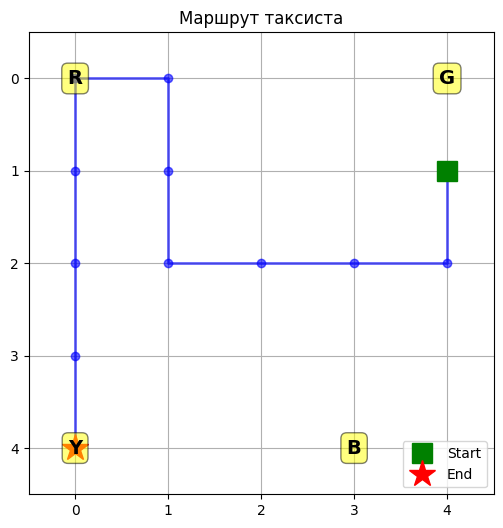

In [25]:
def taxi_pos_from_state(env_taxi, s):
    tr, tc, _, _ = env_taxi.unwrapped.decode(s)
    return tr, tc

def draw_taxi_route(trajectory, env_taxi):
    positions = [taxi_pos_from_state(env_taxi, s) for s in trajectory]
    rows = [p[0] for p in positions]
    cols = [p[1] for p in positions]

    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    ax.plot(cols, rows, 'b-o', markersize=6, linewidth=2, alpha=0.6)
    ax.plot(cols[0], rows[0], 'gs', markersize=15, label='Start')
    ax.plot(cols[-1], rows[-1], 'r*', markersize=20, label='End')

    locs = [(0, 0, 'R'), (0, 4, 'G'), (4, 0, 'Y'), (4, 3, 'B')]
    for r, c, name in locs:
        ax.annotate(name, (c, r), fontsize=14, fontweight='bold', ha='center', va='center',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.5))

    ax.set_xlim(-0.5, 4.5)
    ax.set_ylim(4.5, -0.5)
    ax.set_xticks(range(5))
    ax.set_yticks(range(5))
    ax.grid(True)
    ax.set_title("Маршрут таксиста")
    ax.legend()
    plt.show()

eplot = gym.make("Taxi-v3")
draw_taxi_route(trajectory, eplot)
eplot.close()

### Демонстрация на различных вариантах поля

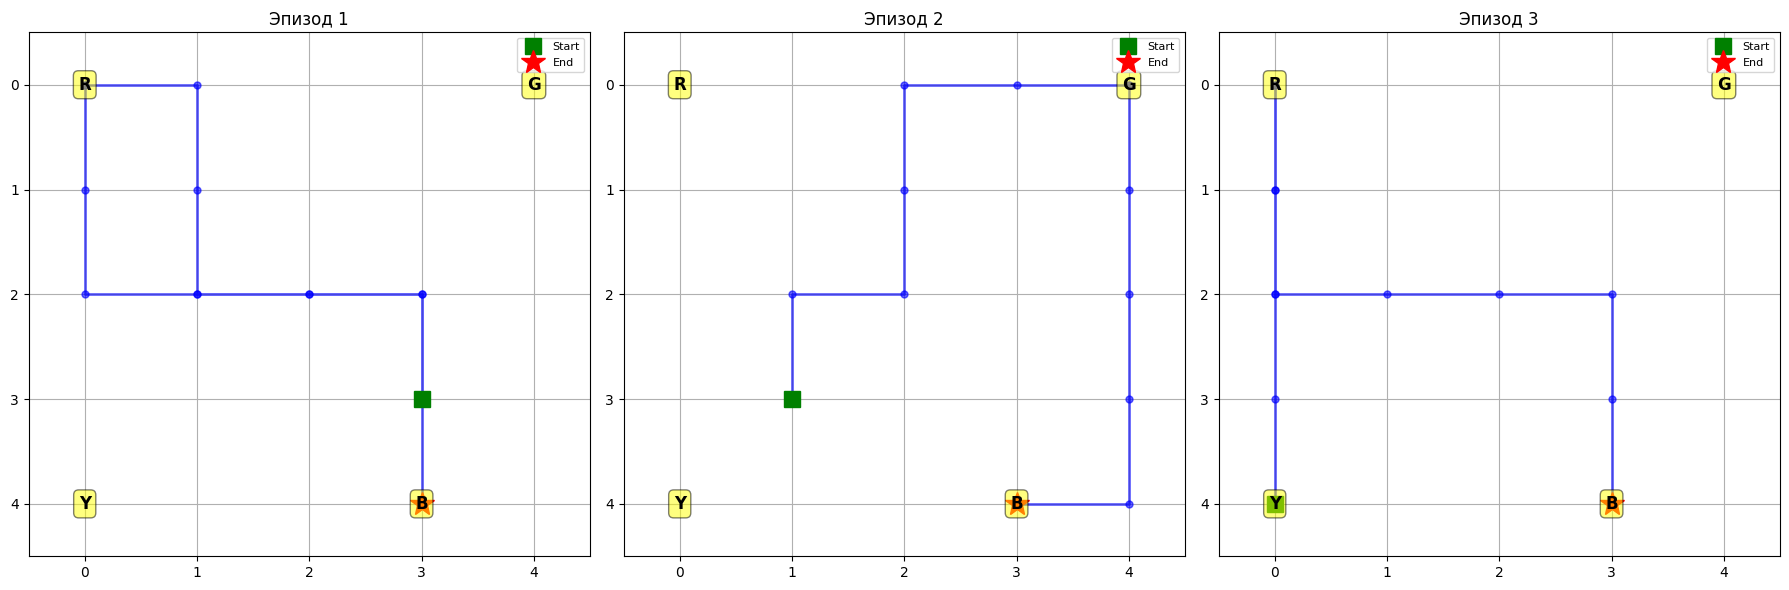

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
e3 = gym.make("Taxi-v3")
for idx, ax in enumerate(axes):
    s = e3.reset()
    traj = [s]
    for t in range(200):
        a = get_optimal_action(taxi_mdp, state_values, s, GAMMA_TAXI)
        if a is None:
            break
        s, r, done, _ = e3.step(a)
        traj.append(s)
        if done:
            break
    positions = [taxi_pos_from_state(e3, st) for st in traj]
    rows = [p[0] for p in positions]
    cols = [p[1] for p in positions]
    ax.plot(cols, rows, 'b-o', markersize=5, linewidth=2, alpha=0.6)
    ax.plot(cols[0], rows[0], 'gs', markersize=12, label='Start')
    ax.plot(cols[-1], rows[-1], 'r*', markersize=18, label='End')
    locs = [(0, 0, 'R'), (0, 4, 'G'), (4, 0, 'Y'), (4, 3, 'B')]
    for r, c, name in locs:
        ax.annotate(name, (c, r), fontsize=12, fontweight='bold', ha='center', va='center',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.5))
    ax.set_xlim(-0.5, 4.5)
    ax.set_ylim(4.5, -0.5)
    ax.set_xticks(range(5))
    ax.set_yticks(range(5))
    ax.grid(True)
    ax.set_title(f"Эпизод {idx + 1}")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
e3.close()

### Сходимость Value Function

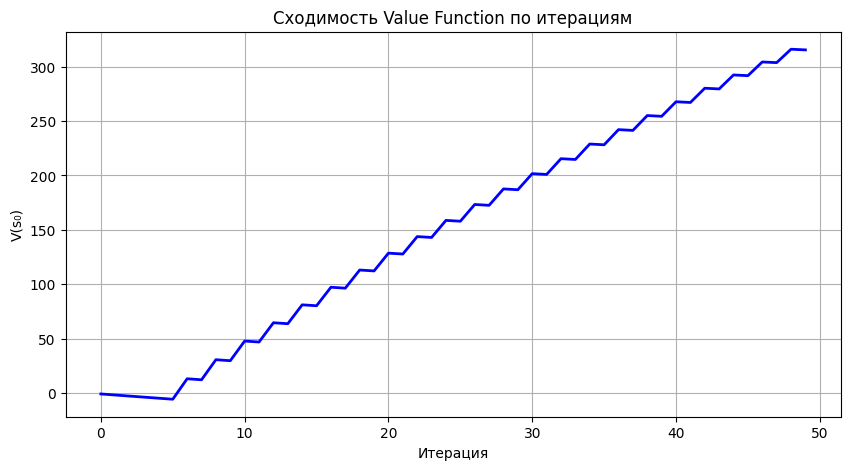

In [27]:
plt.figure(figsize=(10, 5))
plt.plot(history, 'b-', linewidth=2)
plt.xlabel('Итерация')
plt.ylabel('V(s₀)')
plt.title('Сходимость Value Function по итерациям')
plt.grid(True)
plt.show()

### Среднее вознаграждение агента

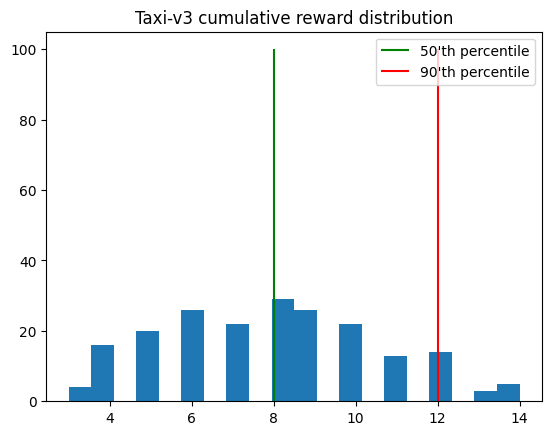

In [28]:
def generate_episode_optimal(env, episode_length=10**4):
    states, actions = [], []
    total_reward = 0.

    s = env.reset()

    for t in range(episode_length):

        a = get_optimal_action(taxi_mdp, state_values, s, GAMMA_TAXI)

        new_s, r, done, info = env.step(a)

        states.append(s)
        actions.append(a)
        total_reward += r

        s = new_s
        if done:
            break

    return states, actions, total_reward

num_episodes = 200
env_eval = gym.make("Taxi-v3")
sample_cumulative_rewards = [generate_episode_optimal(env_eval, episode_length=1000)[-1] for _ in range(num_episodes)]

plt.hist(sample_cumulative_rewards, bins=20)
plt.vlines([np.percentile(sample_cumulative_rewards, 50)], [0], [100], label="50'th percentile", color='green')
plt.vlines([np.percentile(sample_cumulative_rewards, 90)], [0], [100], label="90'th percentile", color='red')
plt.title("Taxi-v3 cumulative reward distribution")
plt.legend()
plt.show()
env_eval.close()